<a href="https://colab.research.google.com/github/AKBER-HUSSAIN/DL-2026/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

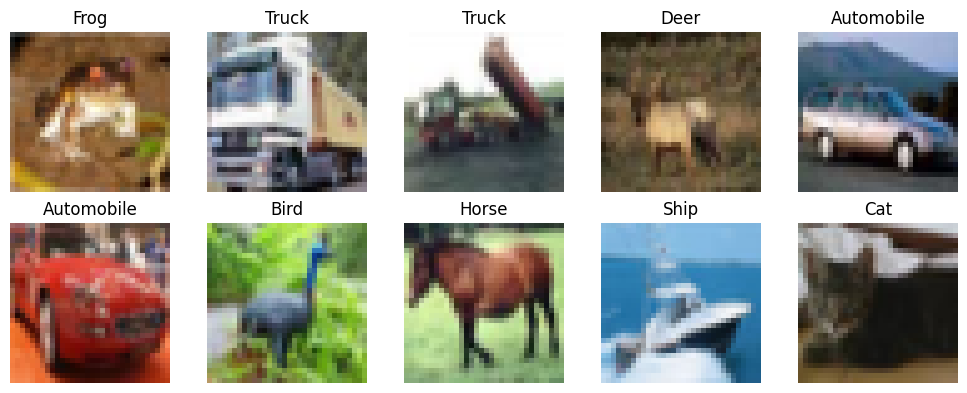

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# Class labels
class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

# Plot first 10 images
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


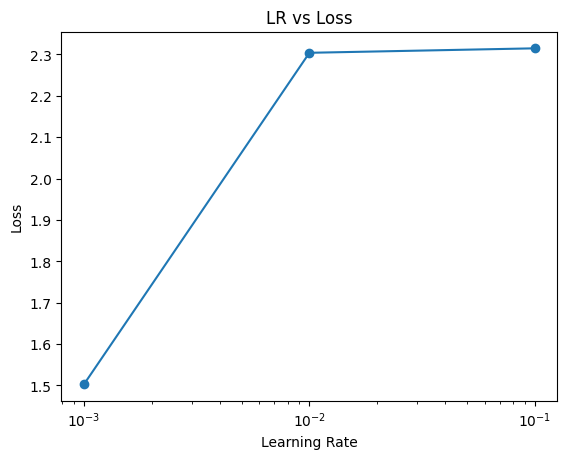

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

learning_rates = [0.1, 0.01, 0.001]
losses = []

for lr in learning_rates:
    model = Sequential([
        Flatten(input_shape=(32,32,3)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=5, verbose=0)

    losses.append(history.history['loss'][-1])

plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("LR vs Loss")
plt.show()

From the experiment, I observed that a smaller learning rate (0.001) resulted in lower loss and stable training. As the learning rate increased, the loss also increased, indicating unstable learning. Hence, choosing an optimal learning rate is important for better performance.

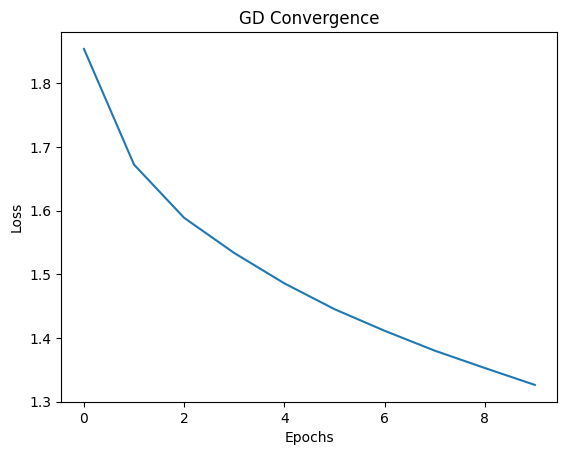

In [4]:
model = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.SGD(0.01),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, verbose=0)

plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("GD Convergence")
plt.show()

The loss curve shows a gradual decrease over epochs, indicating that the model is learning properly. There are no sudden fluctuations, which means the training process is stable and converging effectively.

In [5]:
params = [(0.1,5),(0.01,10),(0.001,15)]

for lr, ep in params:
    model = Sequential([
        Flatten(input_shape=(32,32,3)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=ep, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(lr, ep, acc)

0.1 5 0.10000000149011612
0.01 10 0.24040000140666962
0.001 15 0.4941999912261963


It is observed that a lower learning rate combined with more epochs gives better accuracy. Higher learning rates result in poor performance, while increasing epochs helps the model learn better patterns.


Training with BGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0888 - loss: 2.3580
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step - accuracy: 0.0920 - loss: 2.3314
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 0.1034 - loss: 2.3169
BGD Accuracy: 0.1182, Loss: 2.3040

Training with SGD
Epoch 1/3
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 116s 2ms/step - accuracy: 0.2392 - loss: 2.0702
Epoch 2/3
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 113s 2ms/step - accuracy: 0.2831 - loss: 1.9937
Epoch 3/3
50000/50000 ━━━━━━━━━━━━━━━━━━━━ 111s 2ms/step - accuracy: 0.2994 - loss: 1.9640
SGD Accuracy: 0.3352, Loss: 1.8672

Training with MiniBatch
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3133 - loss: 1.9271
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3821 - loss: 1.7631
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4072 - loss: 1.6919
MiniBatch Accuracy: 0.3795, Loss: 1.7313

Training with Momentum
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/s

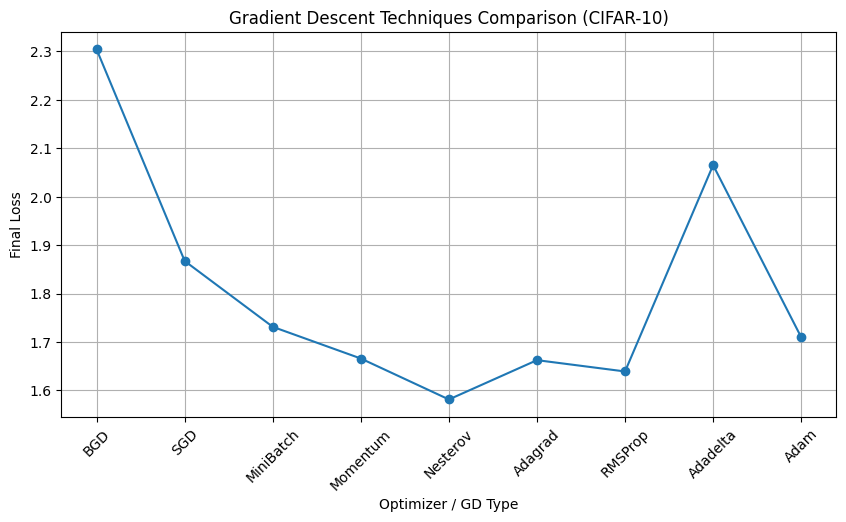


Final Results: {'BGD': 2.3040032386779785, 'SGD': 1.8671921491622925, 'MiniBatch': 1.731331467628479, 'Momentum': 1.6659101247787476, 'Nesterov': 1.5813696384429932, 'Adagrad': 1.662533164024353, 'RMSProp': 1.6391727924346924, 'Adadelta': 2.065171718597412, 'Adam': 1.7099347114562988}


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# ----------------------------
# Load CIFAR
# ----------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

# ----------------------------
# Model builder
# ----------------------------
def build_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ----------------------------
# Optimizers
# ----------------------------
optimizers_dict = {
    "BGD": optimizers.SGD(0.01),
    "SGD": optimizers.SGD(0.01),
    "MiniBatch": optimizers.SGD(0.01),
    "Momentum": optimizers.SGD(0.01, momentum=0.9),
    "Nesterov": optimizers.SGD(0.01, momentum=0.9, nesterov=True),
    "Adagrad": optimizers.Adagrad(0.01),
    "RMSProp": optimizers.RMSprop(0.001),
    "Adadelta": optimizers.Adadelta(),
    "Adam": optimizers.Adam(0.001)
}

results = {}

# ----------------------------
# Training loop
# ----------------------------
for name, opt in optimizers_dict.items():
    print(f"\nTraining with {name}")

    model = build_model()

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Batch size decides GD type
    if name == "BGD":
        batch_size = len(X_train)
    elif name == "SGD":
        batch_size = 1
    else:
        batch_size = 64

    history = model.fit(
        X_train, y_train,
        epochs=3,
        batch_size=batch_size,
        verbose=1
    )

    loss, acc = model.evaluate(X_test,y_test, verbose=0)

    print(f"{name} Accuracy: {acc:.4f}, Loss: {loss:.4f}")

    results[name] = loss

# ----------------------------
# Plot Graph
# ----------------------------
names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(10,5))
plt.plot(names, values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Optimizer / GD Type")
plt.ylabel("Final Loss")
plt.title("Gradient Descent Techniques Comparison (CIFAR-10)")
plt.grid()
plt.show()

print("\nFinal Results:", results)

Different optimization techniques show varying performance. Basic Gradient Descent performs poorly, while methods like Momentum and Nesterov improve convergence speed. Adaptive optimizers like Adam and RMSProp also give good results. Overall, Nesterov performs the best in this case.


L2 Regularization
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3229 - loss: 2.0243
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3792 - loss: 1.8021
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3898 - loss: 1.7741

Dropout
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1607 - loss: 2.1853
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1667 - loss: 2.1402
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1746 - loss: 2.1346

Data Augmentation
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3019 - loss: 1.9345
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3600 - loss: 1.7882
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3801 - loss: 1.7384

Noise Injection
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3263 - loss: 1.8790
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3791 - loss: 1.7290
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4035 - loss: 1.6777
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4160 - loss: 1.6415
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4230 - loss: 1.6202
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4310 - loss: 1.5998
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4361 - loss: 1.5859
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4416 - loss: 1.5701
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4438 - loss: 1.5624
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4471 - loss: 1.5526

Ensemble


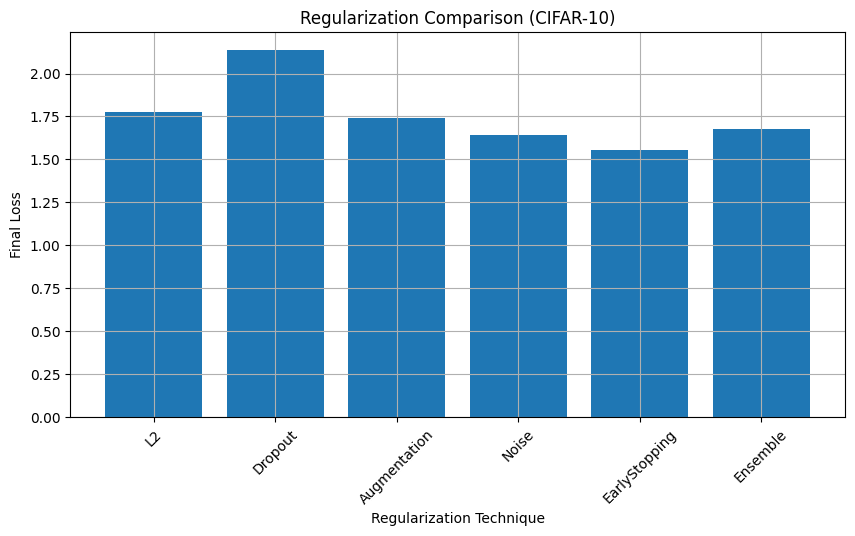


Final Results: {'L2': 1.7740947008132935, 'Dropout': 2.134634017944336, 'Augmentation': 1.7383625507354736, 'Noise': 1.6425297260284424, 'EarlyStopping': 1.5526384115219116, 'Ensemble': 1.6775169372558594, 'ParameterSharing': None}


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load CIFAR
# ----------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

# ----------------------------
# Model builder
# ----------------------------
def build_model(l2_reg=0, dropout_rate=0):
    model = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),

        layers.Dropout(dropout_rate),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

results = {}

# ----------------------------
# 1. L2 Regularization
# ----------------------------
print("\nL2 Regularization")
model = build_model(l2_reg=0.001)
history = model.fit(X_train, y_train, epochs=3, verbose=1)
results["L2"] = history.history['loss'][-1]

# ----------------------------
# 2. Dropout
# ----------------------------
print("\nDropout")
model = build_model(dropout_rate=0.5)
history = model.fit(X_train, y_train, epochs=3, verbose=1)
results["Dropout"] = history.history['loss'][-1]

# ----------------------------
# 3. Data Augmentation
# ----------------------------
print("\nData Augmentation")

data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1)
])

X_aug = data_aug(X_train)

model = build_model()
history = model.fit(X_aug, y_train, epochs=3, verbose=1)
results["Augmentation"] = history.history['loss'][-1]

# ----------------------------
# 4. Noise Injection
# ----------------------------
print("\nNoise Injection")

noise = tf.random.normal(shape=tf.shape(X_train), stddev=0.1)
X_noisy = X_train + noise

model = build_model()
history = model.fit(X_noisy, y_train, epochs=3, verbose=1)
results["Noise"] = history.history['loss'][-1]

# ----------------------------
# 5. Early Stopping
# ----------------------------
print("\nEarly Stopping")

early = callbacks.EarlyStopping(patience=1)

model = build_model()
history = model.fit(X_train, y_train,
                    epochs=10,
                    callbacks=[early],
                    verbose=1)

results["EarlyStopping"] = history.history['loss'][-1]

# ----------------------------
# 6. Ensemble
# ----------------------------
print("\nEnsemble")

models_list = []

for i in range(2):
    m = build_model()
    m.fit(X_train, y_train, epochs=2, verbose=0)
    models_list.append(m)

loss_vals = [m.evaluate(X_test, y_test, verbose=0)[0] for m in models_list]
results["Ensemble"] = sum(loss_vals)/len(loss_vals)

# ----------------------------
# 7. Parameter Sharing
# ----------------------------
# Not applicable for MLP
results["ParameterSharing"] = None

# ----------------------------
# FILTER FOR PLOTTING
# ----------------------------
filtered_results = {k:v for k,v in results.items() if isinstance(v, float)}

# ----------------------------
# PLOT GRAPH
# ----------------------------
plt.figure(figsize=(10,5))
plt.bar(filtered_results.keys(), filtered_results.values())
plt.xticks(rotation=45)
plt.xlabel("Regularization Technique")
plt.ylabel("Final Loss")
plt.title("Regularization Comparison (CIFAR-10)")
plt.grid()
plt.show()

print("\nFinal Results:", results)

Among all regularization methods, early stopping gives the best performance by preventing overfitting. Data augmentation and noise injection also improve generalization. Dropout reduces performance slightly in this case.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

print("\nTraining Basic CNN")

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=5)

loss, acc = model.evaluate(X_test,y_test)
print("Basic CNN Accuracy:", acc)


Training Basic CNN


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5011 - loss: 1.3889 - val_accuracy: 0.6013 - val_loss: 1.1400
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6415 - loss: 1.0268 - val_accuracy: 0.6628 - val_loss: 0.9743
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6929 - loss: 0.8806 - val_accuracy: 0.6639 - val_loss: 0.9873
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7276 - loss: 0.7789 - val_accuracy: 0.7010 - val_loss: 0.8738
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7577 - loss: 0.6947 - val_accuracy: 0.7052 - val_loss: 0.8808
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7052 - loss: 0.8808
Basic CNN Accuracy: 0.7052000164985657


The CNN model performs significantly better than MLP. The accuracy improves steadily during training and reaches around 70%, showing that CNN is effective for image classification tasks.

In [14]:
filters = [32, 64]
learning_rates = [0.001, 0.0005]
batch_sizes = [32, 64]

results = {}

for f in filters:
    for lr in learning_rates:
        for bs in batch_sizes:

            print(f"\nFilters={f}, LR={lr}, Batch={bs}")

            model = models.Sequential([
                layers.Conv2D(f, (3,3), activation='relu', input_shape=(32,32,3)),
                layers.MaxPooling2D((2,2)),

                layers.Conv2D(f*2, (3,3), activation='relu'),
                layers.MaxPooling2D((2,2)),

                layers.Flatten(),
                layers.Dense(128, activation='relu'),
                layers.Dense(10, activation='softmax')
            ])

            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )

            model.fit(X_train, y_train, epochs=3, batch_size=bs, verbose=0)

            loss, acc = model.evaluate(X_test,y_test, verbose=0)

            results[(f, lr, bs)] = acc

print("\nResults:", results)


Filters=32, LR=0.001, Batch=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Filters=32, LR=0.001, Batch=64

Filters=32, LR=0.0005, Batch=32

Filters=32, LR=0.0005, Batch=64

Filters=64, LR=0.001, Batch=32

Filters=64, LR=0.001, Batch=64

Filters=64, LR=0.0005, Batch=32

Filters=64, LR=0.0005, Batch=64

Results: {(32, 0.001, 32): 0.6714000105857849, (32, 0.001, 64): 0.6572999954223633, (32, 0.0005, 32): 0.6349999904632568, (32, 0.0005, 64): 0.618399977684021, (64, 0.001, 32): 0.6966000199317932, (64, 0.001, 64): 0.6718999743461609, (64, 0.0005, 32): 0.680899977684021, (64, 0.0005, 64): 0.6625000238418579}


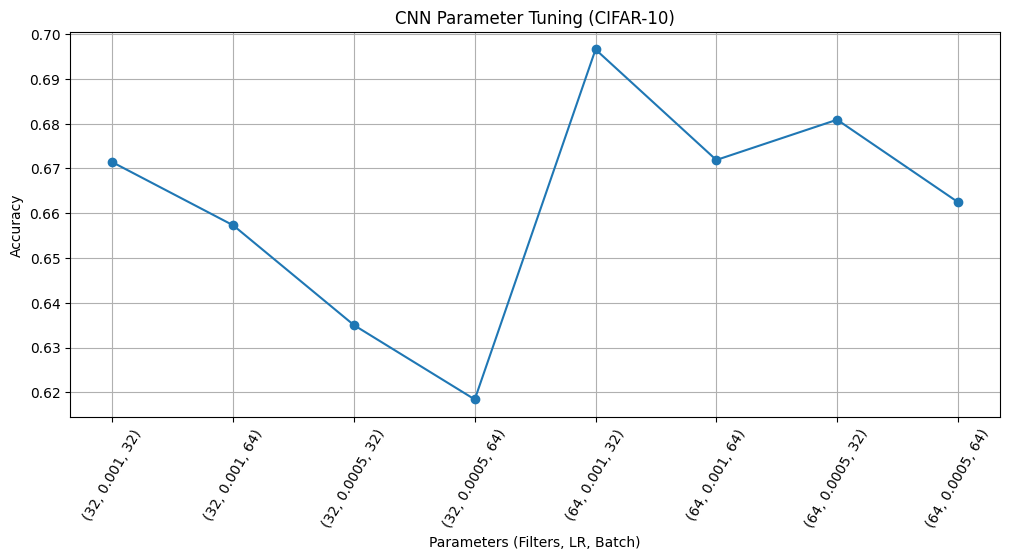

In [15]:
labels = [str(k) for k in results.keys()]
values = list(results.values())

plt.figure(figsize=(12,5))
plt.plot(labels, values, marker='o')
plt.xticks(rotation=60)
plt.xlabel("Parameters (Filters, LR, Batch)")
plt.ylabel("Accuracy")
plt.title("CNN Parameter Tuning (CIFAR-10)")
plt.grid()
plt.show()

Increasing the number of filters improves feature extraction and model performance. A lower learning rate and smaller batch size provide better accuracy. The best performance is achieved with 64 filters, learning rate 0.001, and batch size 32.

In [16]:
best = max(results, key=results.get)
print("Best Parameters:", best)
print("Best Accuracy:", results[best])

Best Parameters: (64, 0.001, 32)
Best Accuracy: 0.6966000199317932


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

results = {}

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [2]:
print("\nLeNet Model")

model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(6, (5,5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16, (5,5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5, verbose=1)
loss, acc = model.evaluate(X_test, y_test)
print("LeNet Accuracy:", acc)

results["LeNet"] = acc


LeNet Model
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4179 - loss: 1.6035
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5245 - loss: 1.3294
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5650 - loss: 1.2209
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5909 - loss: 1.1467
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6140 - loss: 1.0851
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5907 - loss: 1.1536
LeNet Accuracy: 0.5906999707221985


In [3]:
print("\nAlexNet Model (FIXED)")

model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(96, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(384, (3,3), activation='relu', padding='same'),
    layers.Conv2D(384, (3,3), activation='relu', padding='same'),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)
loss, acc = model.evaluate(X_test, y_test)
print("AlexNet Accuracy:", acc)


AlexNet Model (FIXED)
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.4234 - loss: 1.5607
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - accuracy: 0.5995 - loss: 1.1254
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6750 - loss: 0.9181
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7296 - loss: 0.7674
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7731 - loss: 0.6447
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7111 - loss: 0.8455
AlexNet Accuracy: 0.7110999822616577


In [4]:
print("\nZF-Net Model")

model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)
loss, acc = model.evaluate(X_test, y_test)
print("ZF-Net Accuracy:", acc)

results["ZF-Net"] = acc


ZF-Net Model
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4982 - loss: 1.3840
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6586 - loss: 0.9706
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7281 - loss: 0.7793
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7768 - loss: 0.6344
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8208 - loss: 0.5067
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7360 - loss: 0.7988
ZF-Net Accuracy: 0.7360000014305115


In [5]:
print("\nVGG Model")

model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)
loss, acc = model.evaluate(X_test, y_test)
print("VGG Accuracy:", acc)

results["VGG"] = acc


VGG Model
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.5420 - loss: 1.2706
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7154 - loss: 0.8032
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7936 - loss: 0.5905
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8543 - loss: 0.4120
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9051 - loss: 0.2697
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7509 - loss: 0.9289
VGG Accuracy: 0.7508999705314636


In [6]:
print("\nResNet Model")

base = tf.keras.applications.ResNet50(
    weights=None,
    include_top=False,
    input_shape=(32,32,3)
)

x = layers.Flatten()(base.output)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=3)
loss, acc = model.evaluate(X_test, y_test)
print("ResNet Accuracy:", acc)

results["ResNet"] = acc


ResNet Model
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 116s 41ms/step - accuracy: 0.3549 - loss: 1.7690
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.4393 - loss: 1.5327
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.4276 - loss: 1.5733
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4340 - loss: 1.6425
ResNet Accuracy: 0.4339999854564667


In [7]:
print("\nInception Model")

# Resize CIFAR
X_train_resized = tf.image.resize(X_train, (75,75))
X_test_resized = tf.image.resize(X_test, (75,75))

base = tf.keras.applications.InceptionV3(
    weights=None,
    include_top=False,
    input_shape=(75,75,3)
)

x = layers.Flatten()(base.output)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_resized, y_train, epochs=3)
loss, acc = model.evaluate(X_test_resized, y_test)
print("Inception Accuracy:", acc)

results["Inception"] = acc


Inception Model
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 179s 68ms/step - accuracy: 0.3716 - loss: 1.6969
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.3792 - loss: 1.6743
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.4976 - loss: 1.3901
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.3411 - loss: 1.9643
Inception Accuracy: 0.3411000072956085


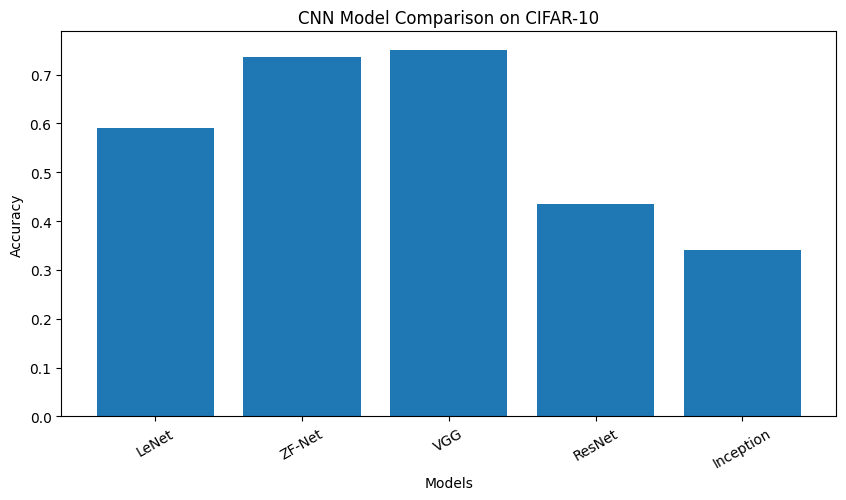


Final Results: {'LeNet': 0.5906999707221985, 'ZF-Net': 0.7360000014305115, 'VGG': 0.7508999705314636, 'ResNet': 0.4339999854564667, 'Inception': 0.3411000072956085}


In [8]:
names = list(results.keys())
values = list(results.values())

plt.figure(figsize=(10,5))
plt.bar(names, values)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("CNN Model Comparison on CIFAR-10")
plt.xticks(rotation=30)
plt.show()

print("\nFinal Results:", results)

Among all models, VGG gives the best accuracy due to its deeper architecture. ZF-Net and AlexNet also perform well. ResNet and Inception show lower performance, possibly due to lack of pretraining and small input size.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step


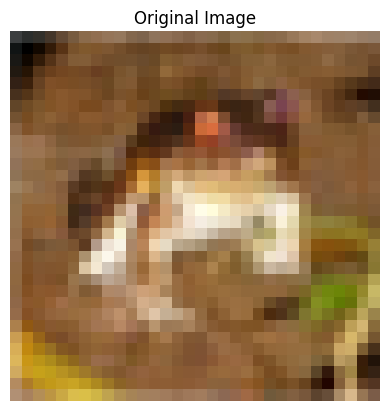


Layer 1 Output Shape: (1, 32, 32, 32)


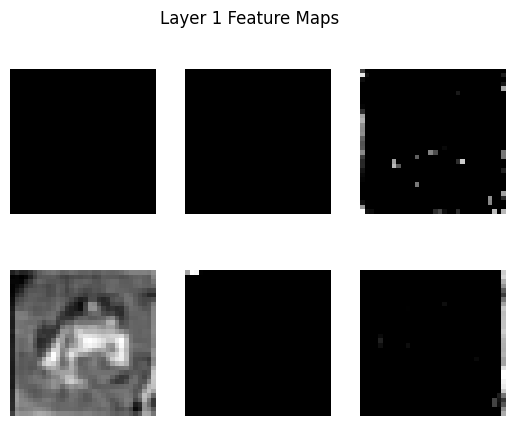


Layer 2 Output Shape: (1, 16, 16, 32)


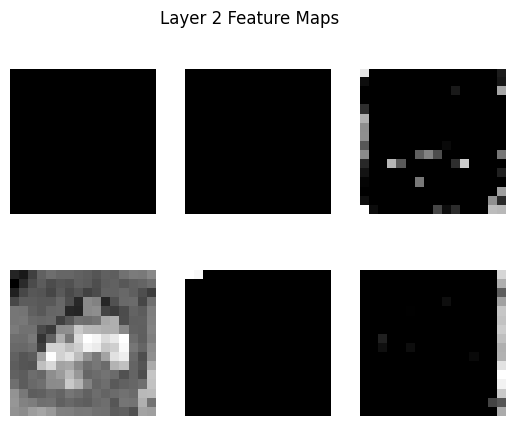


Layer 3 Output Shape: (1, 16, 16, 64)


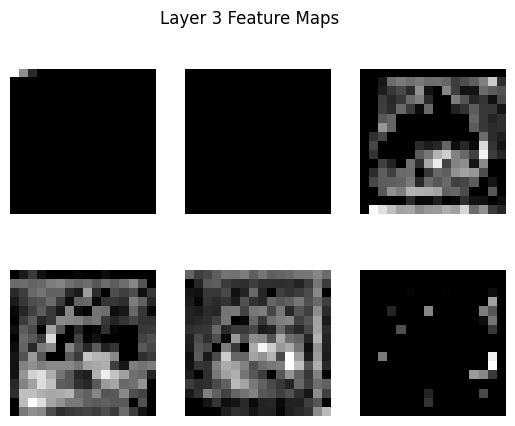


Layer 4 Output Shape: (1, 8, 8, 64)


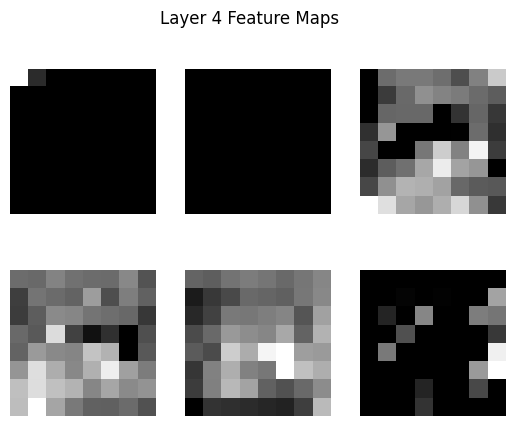


Layer 5 Output Shape: (1, 8, 8, 128)


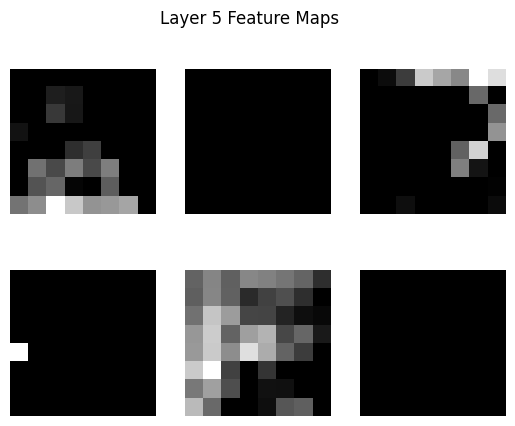

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Load CIFAR dataset
# ----------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0

# ----------------------------
# Select one image
# ----------------------------
img = X_train[0]
img = np.expand_dims(img, axis=0)

# ----------------------------
# Build CNN model
# ----------------------------
model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same')
])

# ----------------------------
# IMPORTANT FIX: call model once
# ----------------------------
model.predict(img)

# ----------------------------
# Create feature map model
# ----------------------------
layer_outputs = [layer.output for layer in model.layers]

feature_model = tf.keras.Model(inputs=model.inputs,
                               outputs=layer_outputs)

# ----------------------------
# Get feature maps
# ----------------------------
feature_maps = feature_model.predict(img)

# ----------------------------
# Show original image
# ----------------------------
plt.imshow(img[0])
plt.title("Original Image")
plt.axis('off')
plt.show()

# ----------------------------
# Show feature maps
# ----------------------------
for i, fmap in enumerate(feature_maps):

    print(f"\nLayer {i+1} Output Shape:", fmap.shape)

    num_filters = fmap.shape[-1]

    # show first 6 feature maps
    for j in range(min(6, num_filters)):
        plt.subplot(2,3,j+1)
        plt.imshow(fmap[0,:,:,j], cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Layer {i+1} Feature Maps")
    plt.show()

The feature maps show how the CNN processes images step by step. Initial layers detect edges and simple patterns, while deeper layers capture complex features. This demonstrates how CNN learns hierarchical representations.

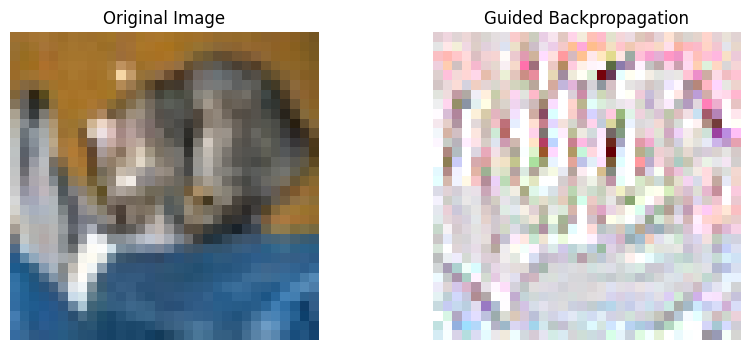

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load CIFAR
# ----------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = y_train.flatten()
y_test = y_test.flatten()

# ----------------------------
# Build simple CNN
# ----------------------------
model = models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train briefly
model.fit(X_train, y_train, epochs=3, verbose=0)

# ----------------------------
# Select one image
# ----------------------------
img = X_test[0]
img = np.expand_dims(img, axis=0)

# ----------------------------
# Guided Backprop Function
# ----------------------------
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        return tf.cast(dy > 0, "float32") * tf.cast(x > 0, "float32") * dy
    return tf.nn.relu(x), grad

# Replace ReLU with Guided ReLU
for layer in model.layers:
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        layer.activation = guided_relu

# ----------------------------
# Compute Gradients
# ----------------------------
# Convert to tensor (IMPORTANT FIX)
img = tf.convert_to_tensor(img, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img)
    preds = model(img)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, img)[0]

# Normalize gradients
grads = (grads - tf.reduce_min(grads)) / (tf.reduce_max(grads) + 1e-8)

# ----------------------------
# Plot results
# ----------------------------
plt.figure(figsize=(10,4))

# Original image
plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Original Image")
plt.axis('off')

# Guided Backprop map
plt.subplot(1,2,2)
plt.imshow(grads)
plt.title("Guided Backpropagation")
plt.axis('off')

plt.show()

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0373 - val_loss: 0.0276
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0249 - val_loss: 0.0227
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0215 - val_loss: 0.0200
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0190 - val_loss: 0.0178
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0169 - val_loss: 0.0159
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0156 - val_loss: 0.0157
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0149 - val_loss: 0.0149
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0141 - val_loss: 0.0136
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0136 - val_loss: 0.0133
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0135 - val_loss: 0.0131
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0132 - val_loss: 0.0139
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/ste

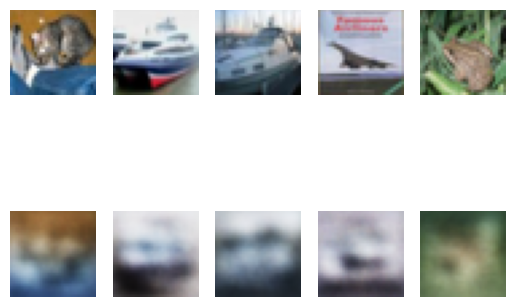

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

# Load data
(x_train, _), (x_test, _) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# Model
input_layer = Input(shape=(3072,))
encoded = Dense(128, activation='relu')(input_layer)
decoded = Dense(3072, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, validation_data=(x_test, x_test))

# Predict
decoded_imgs = autoencoder.predict(x_test)

# Display
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.axis('off')

plt.show()


Training Autoencoder with dimension = 1024
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


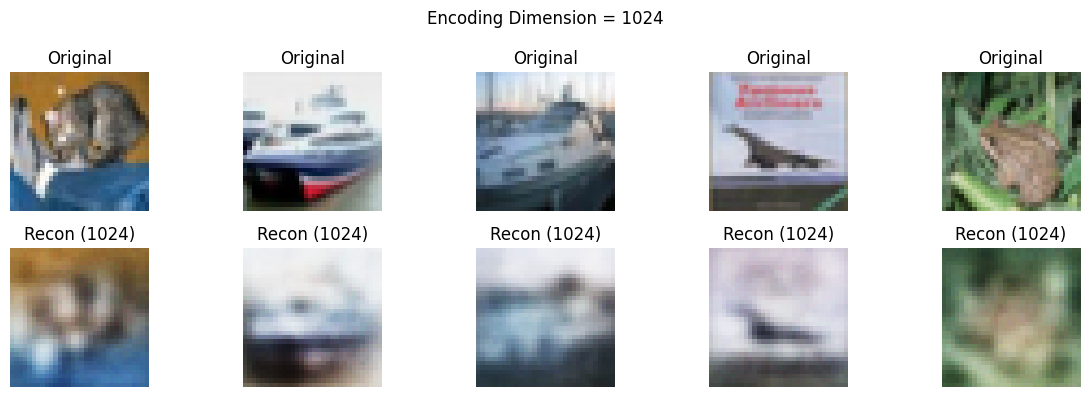


Training Autoencoder with dimension = 512
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


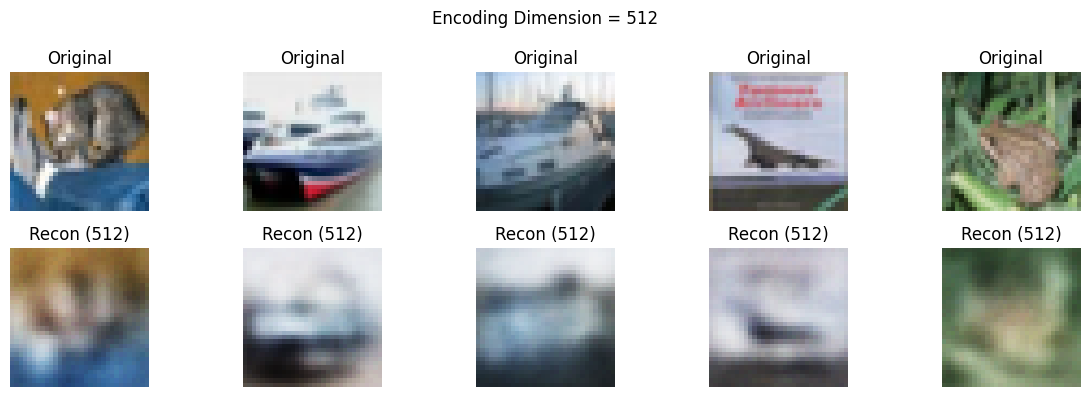


Training Autoencoder with dimension = 128
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


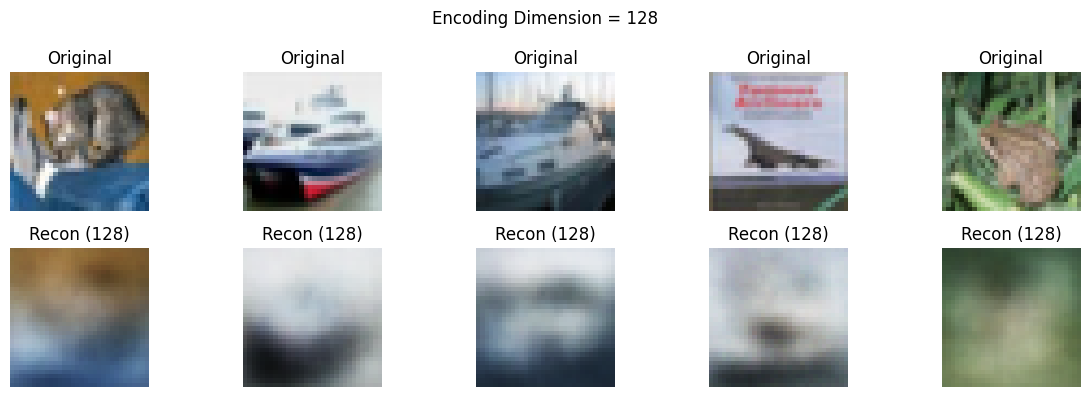


Training Autoencoder with dimension = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


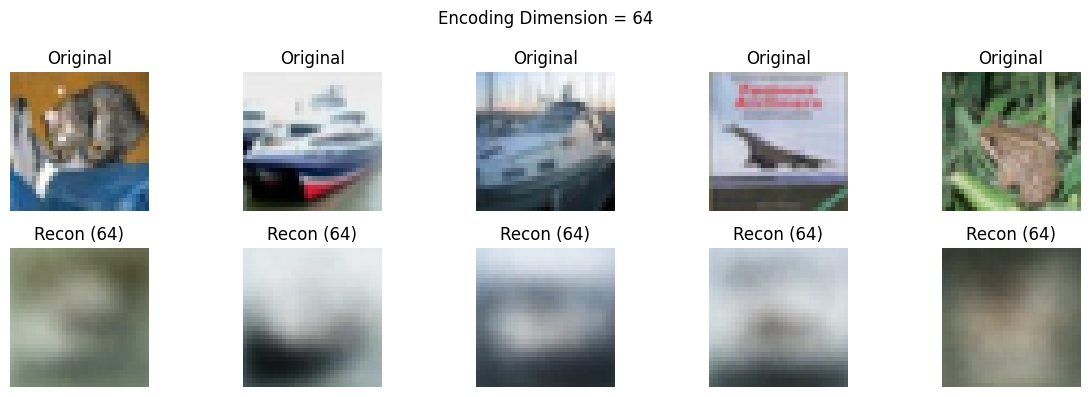


Training Autoencoder with dimension = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


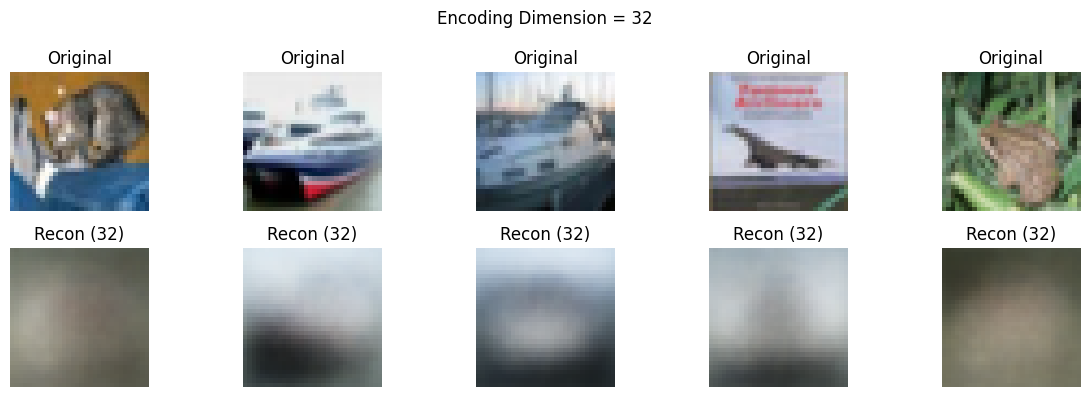


Training Autoencoder with dimension = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


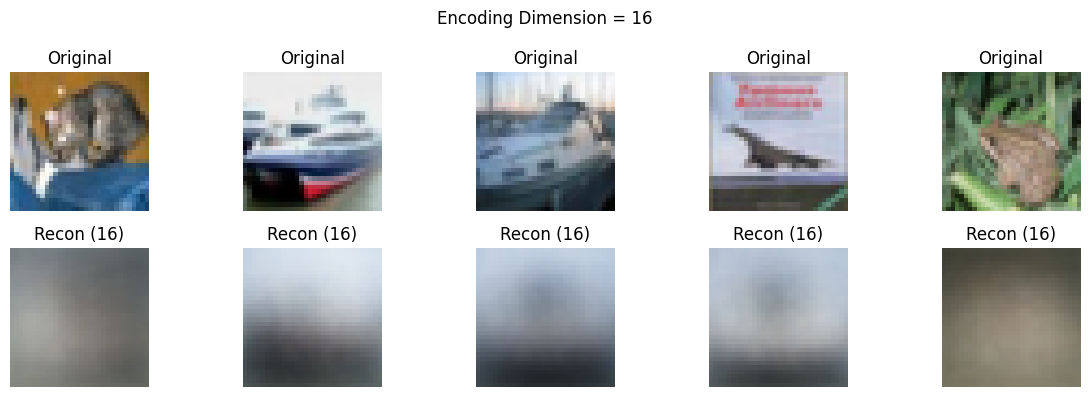

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import tensorflow as tf

# -----------------------------
# 1. Load Data (CIFAR)
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten 32x32x3 → 3072
x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# -----------------------------
# 2. Dimensions to Test
# -----------------------------
dimensions = [1024, 512, 128, 64, 32, 16]  # large → small

# -----------------------------
# 3. Loop Through Each Dimension
# -----------------------------
n = 5  # number of images

for encoding_dim in dimensions:
    print(f"\nTraining Autoencoder with dimension = {encoding_dim}")

    # -----------------------------
    # Encoder
    # -----------------------------
    input_layer = Input(shape=(3072,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # -----------------------------
    # Decoder
    # -----------------------------
    decoded = Dense(3072, activation='sigmoid')(encoded)

    # -----------------------------
    # Models
    # -----------------------------
    autoencoder = Model(input_layer, decoded)
    encoder = Model(input_layer, encoded)

    # -----------------------------
    # Compile
    # -----------------------------
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # -----------------------------
    # Train
    # -----------------------------
    autoencoder.fit(x_train, x_train,
                    epochs=10,
                    batch_size=256,
                    shuffle=True,
                    validation_data=(x_test, x_test),
                    verbose=0)

    # -----------------------------
    # Predict
    # -----------------------------
    encoded_imgs = encoder.predict(x_test)
    decoded_imgs = autoencoder.predict(x_test)

    # -----------------------------
    # Visualization
    # -----------------------------
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"Encoding Dimension = {encoding_dim}")

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(32, 32, 3))
        plt.title("Original")
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(32, 32, 3))
        plt.title(f"Recon ({encoding_dim})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.6653 - val_loss: 0.6263
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6280 - val_loss: 0.6165
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6208 - val_loss: 0.6249
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6165 - val_loss: 0.6109
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6119 - val_loss: 0.6008
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6100 - val_loss: 0.5996
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6082 - val_loss: 0.5981
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6087 - val_loss: 0.5983
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6072 - val_loss: 0.5966
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6068 - val_loss: 0.5971
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


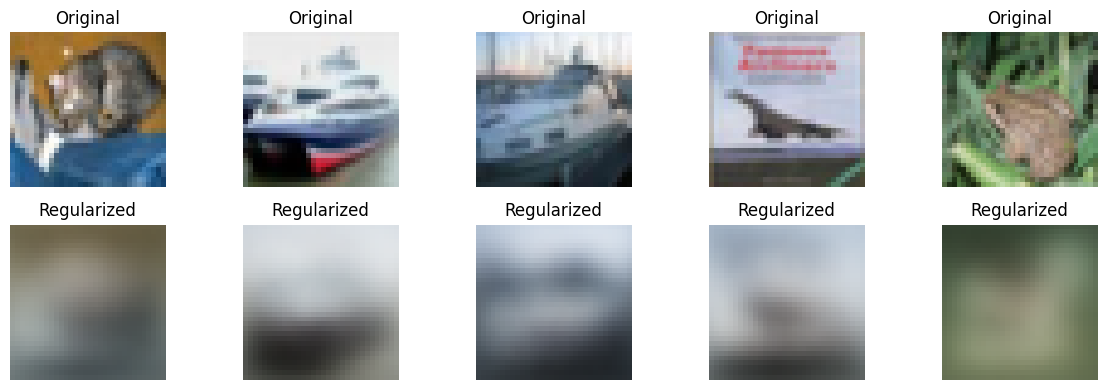

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import tensorflow as tf

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# -----------------------------
# 2. Parameters
# -----------------------------
encoding_dim = 128

# -----------------------------
# 3. Encoder with Regularization
# -----------------------------
input_layer = Input(shape=(3072,))

encoded = Dense(encoding_dim,
                activation='relu',
                kernel_regularizer=regularizers.l2(0.001))(input_layer)

encoded = Dropout(0.3)(encoded)

# -----------------------------
# 4. Decoder
# -----------------------------
decoded = Dense(3072, activation='sigmoid')(encoded)

# -----------------------------
# 5. Model
# -----------------------------
autoencoder = Model(input_layer, decoded)

# -----------------------------
# 6. Compile
# -----------------------------
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# -----------------------------
# 7. Train
# -----------------------------
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# -----------------------------
# 8. Predict
# -----------------------------
decoded_imgs = autoencoder.predict(x_test)

# -----------------------------
# 9. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(12, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.title("Original")
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.title("Regularized")
    ax.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.6431 - val_loss: 0.6225
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6169 - val_loss: 0.6147
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6093 - val_loss: 0.6071
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6039 - val_loss: 0.6028
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6006 - val_loss: 0.5993
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5973 - val_loss: 0.5968
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5948 - val_loss: 0.5950
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5931 - val_loss: 0.5931
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.5922 - val_loss: 0.5969
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5915 - val_loss: 0.5923
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


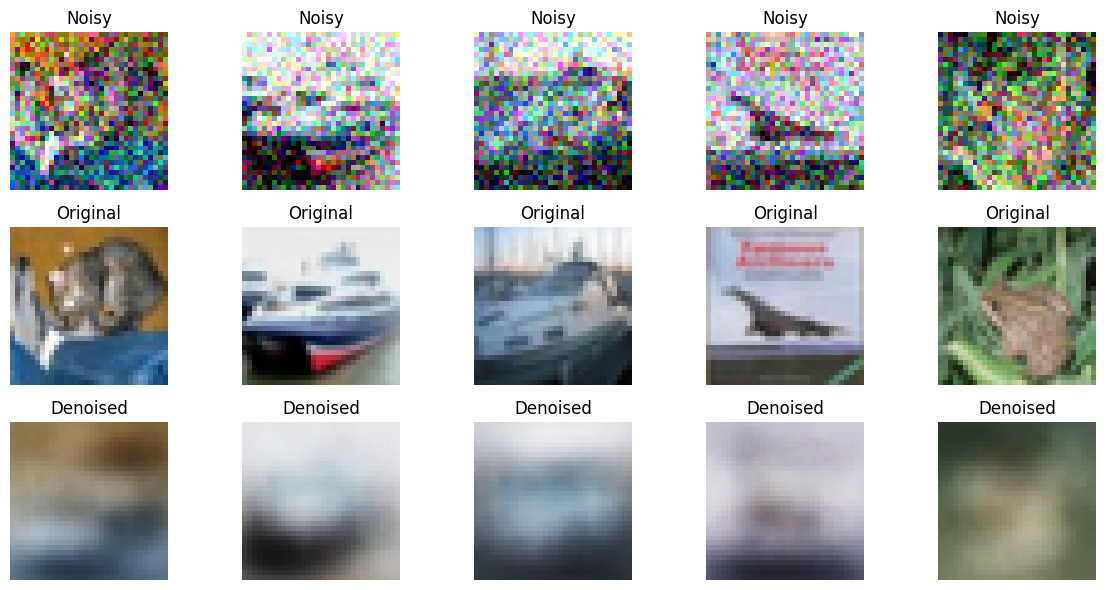

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import tensorflow as tf

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# -----------------------------
# 2. Add Noise
# -----------------------------
noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# -----------------------------
# 3. Model
# -----------------------------
input_layer = Input(shape=(3072,))
encoded = Dense(128, activation='relu')(input_layer)
decoded = Dense(3072, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

# -----------------------------
# 4. Compile
# -----------------------------
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# -----------------------------
# 5. Train (Noisy → Clean)
# -----------------------------
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

# -----------------------------
# 6. Predict
# -----------------------------
decoded_imgs = autoencoder.predict(x_test_noisy)

# -----------------------------
# 7. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # Noisy Input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(32,32,3))
    plt.title("Noisy")
    ax.axis('off')

    # Clean Original
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.title("Original")
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.title("Denoised")
    ax.axis('off')

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


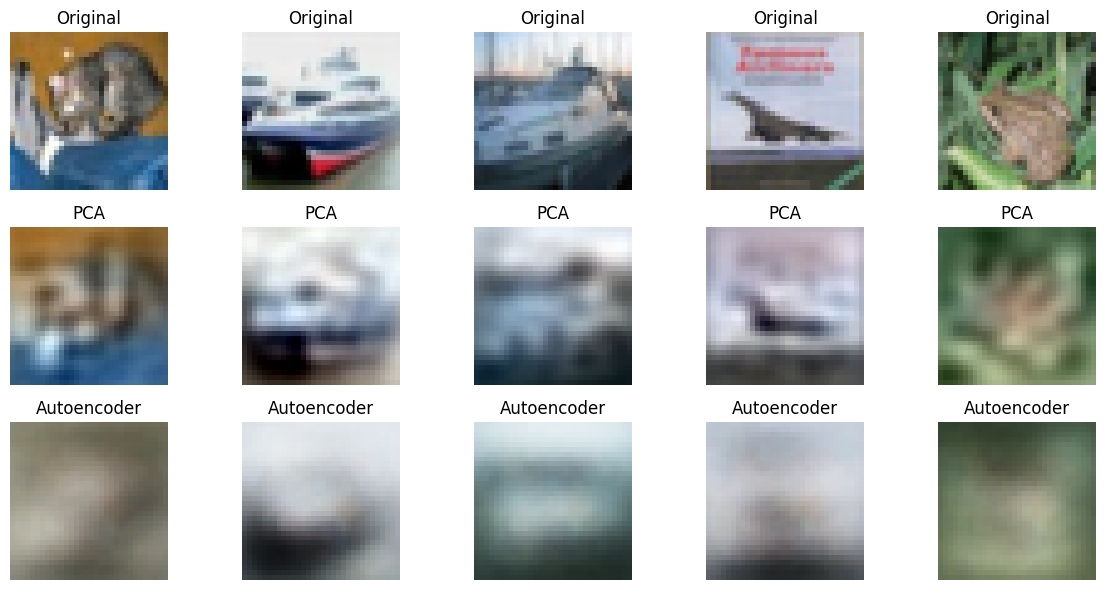

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
import tensorflow as tf

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# -----------------------------
# 2. PCA (Linear)
# -----------------------------
pca = PCA(n_components=100)
x_test_pca = pca.fit_transform(x_test)
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# -----------------------------
# 3. Autoencoder (Non-linear PCA)
# -----------------------------
input_layer = Input(shape=(3072,))
encoded = Dense(100, activation='relu')(input_layer)
decoded = Dense(3072, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test),
                verbose=0)

decoded_imgs = autoencoder.predict(x_test)

# -----------------------------
# 4. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.title("Original")
    ax.axis('off')

    # PCA Reconstruction
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_pca_recon[i].reshape(32,32,3))
    plt.title("PCA")
    ax.axis('off')

    # AE Reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.title("Autoencoder")
    ax.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.6917 - val_loss: 0.6901
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6895 - val_loss: 0.6895
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6892 - val_loss: 0.6894
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6891 - val_loss: 0.6894
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


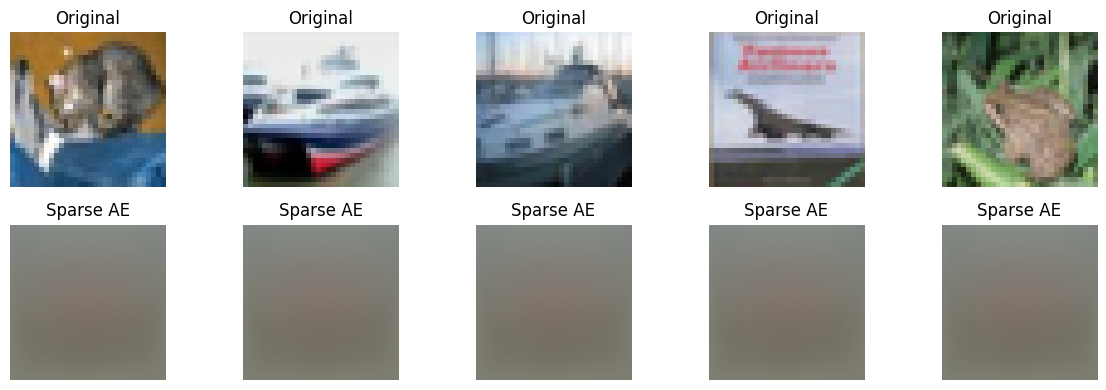

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import tensorflow as tf

# -----------------------------
# 1. Load Data
# -----------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten
x_train = x_train.reshape((len(x_train), 3072))
x_test = x_test.reshape((len(x_test), 3072))

# -----------------------------
# 2. Sparse AE
# -----------------------------
input_layer = Input(shape=(3072,))

encoded = Dense(128,
                activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(input_layer)

decoded = Dense(3072, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

# -----------------------------
# 3. Compile
# -----------------------------
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# -----------------------------
# 4. Train
# -----------------------------
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

# -----------------------------
# 5. Predict
# -----------------------------
decoded_imgs = autoencoder.predict(x_test)

# -----------------------------
# 6. Visualization
# -----------------------------
n = 5
plt.figure(figsize=(12,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(32,32,3))
    plt.title("Original")
    ax.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(32,32,3))
    plt.title("Sparse AE")
    ax.axis('off')

plt.tight_layout()
plt.show()